# How to choose the proper model?

In [1]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import scipy
from astropy.coordinates import angular_separation

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt

# import seaborn as sns
# sns.set_context("poster")

### Combination BFT & SSOFT

In [2]:
cols = [
    "sso_number",
    "sso_name",
    "sso_class",
    "diameter.value",
    "spins.1.period.value",
    "spins.1.RA0.value",
    "spins.1.DEC0.value",
    "spins.1.technique",
    "spins.2.period.value",
    "spins.2.RA0.value",
    "spins.2.DEC0.value",
    "spins.2.technique",
    "family.family_number",
    "family.family_name",
    "orbital_elements.semi_major_axis.value",
    "orbital_elements.eccentricity.value",
    "orbital_elements.inclination.value",
    "proper_elements.proper_semi_major_axis.value",
    "proper_elements.proper_eccentricity.value",
    "proper_elements.proper_inclination.value",
    "proper_elements.proper_sine_inclination.value",
]

# Read BFT with rocks
bft = rocks.load_bft(columns=cols)

In [3]:
# You need SSOFT version 2024.11
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [4]:
flavor = "SSHG1G2"
confidence_fraction = 0.99

In [5]:
# Data cleaning during development
ssoft.columns = ssoft.columns.str.replace("_1_", "_g_")
ssoft.columns = ssoft.columns.str.replace("_2_", "_r_")

ssoft["SSHG1G2_G1_g"] = ssoft["SSHG1G2_G1_g_00"]
ssoft["SSHG1G2_G2_g"] = ssoft["SSHG1G2_G2_g_00"]
ssoft["SSHG1G2_G1_r"] = ssoft["SSHG1G2_G1_r_00"]
ssoft["SSHG1G2_G2_r"] = ssoft["SSHG1G2_G2_r_00"]
ssoft["SSHG1G2_alpha0"] = ssoft["SSHG1G2_alpha0_00"]
ssoft["SSHG1G2_delta0"] = ssoft["SSHG1G2_delta0_00"]

In [6]:
# Test mask on inversion version
thres = 1e-3

versions = ["00", "01", "10", "11"]
for v in versions:
    maskSS = (
        (ssoft[f"SSHG1G2_alpha0_{v}"].notna())
        & (ssoft[f"SSHG1G2_delta0_{v}"].notna())
        & (ssoft[f"SSHG1G2_alpha0_{v}"] > thres)
        & (np.abs(360 - ssoft[f"SSHG1G2_alpha0_{v}"]) > thres)
        & (np.abs(ssoft[f"SSHG1G2_alpha0_{v}"] - 180) > thres)
        & (np.abs(ssoft[f"SSHG1G2_delta0_{v}"]) > thres)
    )

    mask_g = (
        (ssoft[f"SSHG1G2_G1_g_{v}"] > thres)
        & (ssoft[f"SSHG1G2_G2_g_{v}"] > thres)
        & ((1 - ssoft[f"SSHG1G2_G1_g_{v}"] - ssoft[f"SSHG1G2_G2_g_{v}"]) > thres)
    )
    mask_r = (
        (ssoft[f"SSHG1G2_G1_r_{v}"] > thres)
        & (ssoft[f"SSHG1G2_G2_r_{v}"] > thres)
        & ((1 - ssoft[f"SSHG1G2_G1_r_{v}"] - ssoft[f"SSHG1G2_G2_r_{v}"]) > thres)
    )

    mask = maskSS & mask_g & mask_r
    if v == "00":
        mask_all = mask
    else:
        mask_all = mask_all & mask
    print(
        f"{v:2s} {maskSS.sum():5d} {mask_g.sum():5d} {mask_r.sum():5d}  {mask.sum():5d}  {mask_all.sum():5d}"
    )

mask = mask_all

00 126281 88749 95442  74404  74404
01 126347 88831 95680  74658  61733
10 117417 88661 95536  69664  51396
11 117319 88781 95635  69604  45263


In [7]:
data = ssoft[mask].merge(bft, left_on="name", right_on="sso_name", how="left")

In [8]:
data["SSHG1G2_version"] = (
    data[["SSHG1G2_rms_00", "SSHG1G2_rms_01", "SSHG1G2_rms_10", "SSHG1G2_rms_11"]]
    .idxmin(axis=1)
    .str.split("_")
    .str[2]
)

data["SSHG1G2_min"] = data[
    ["SSHG1G2_rms_00", "SSHG1G2_rms_01", "SSHG1G2_rms_10", "SSHG1G2_rms_11"]
].min(axis=1)

data["SSHG1G2_max"] = data[
    ["SSHG1G2_rms_00", "SSHG1G2_rms_01", "SSHG1G2_rms_10", "SSHG1G2_rms_11"]
].max(axis=1)

for v in ["00", "01", "10", "11"]:
    data[f"SSHG1G2_{v}_rms"] = data[f"SSHG1G2_rms_{v}"]

## F-test on the different models

In [9]:
n_params = {
    "HG": 2 * 2,
    "HG12": 2 * 2,
    "HG1G2": 3 * 2,
    "SHG1G2": 3 * 2 + 3,
    "SSHG1G2_00": 3 * 2 + 5,
    "SSHG1G2_01": 3 * 2 + 5,
    "SSHG1G2_10": 3 * 2 + 5,
    "SSHG1G2_11": 3 * 2 + 5,
}

(0.0018, 1)

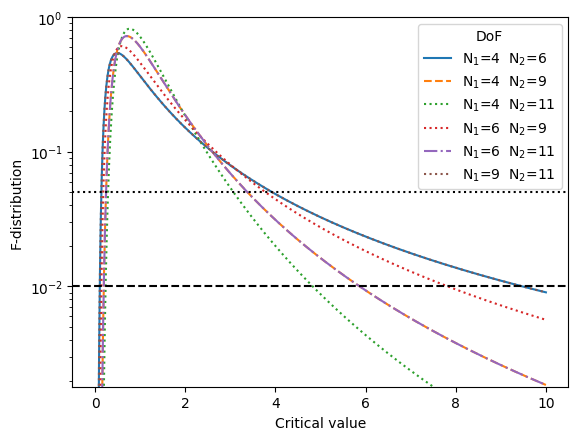

In [10]:
nn = [4, 6, 9, 11] # DoF for HG HGG sHGG ssHGG
N = 200
x = np.linspace(0, 10, 1000)

# Plot the F-distributions
ls = ["solid", "--", "dotted", ":", "-.", "dotted"]
k = 0
fig, ax = plt.subplots()
for i, n1 in enumerate(nn):
    for j, n2 in enumerate(nn[i + 1 :]):

        pdf = scipy.stats.f.pdf(x, dfn=N - n2, dfd=n2 - n1)
        ax.plot(x, pdf, linestyle=ls[k], label=f"N$_1$={n1}  N$_2$={n2}")
        k = k + 1

# One and Five percent confidence levels
ax.axhline(0.01, color="black", linestyle="--")
ax.axhline(0.05, color="black", linestyle="dotted")

# Axes
ax.legend(loc="upper right", title="DoF")
ax.set_xlabel("Critical value")
ax.set_ylabel("F-distribution")
ax.set_yscale("log")
ax.set_ylim(1.8e-3, 1)

In [11]:
models = [
    "HG",
    "HG1G2",
    "SHG1G2",
    "SSHG1G2_00",
    "SSHG1G2_01",
    "SSHG1G2_10",
    "SSHG1G2_11",
]
for i, m1 in enumerate(models[:3]):
    for j, m2 in enumerate(models[i + 1 :]):
        # print(m1,m2)

        # https://en.wikipedia.org/wiki/F-test ... wikipedia... I know

        N = data[f"SSHG1G2_n_obs_10"].values  # TBD
        F = ((data[f"{m1}_rms"] ** 2) / (data[f"{m2}_rms"] ** 2) - 1) * (
            (N - n_params[m2]) / (n_params[m2] - n_params[m1])
        )
        data[f"F_{m1}_{m2}"] = F
        
        # Mauvaise (?) version
        data["alpha"] = scipy.stats.f.ppf(
            q=confidence_fraction, dfn=N - n_params[m2], dfd=n_params[m2] - n_params[m1] 
        )

        # Correct version
        data["alpha"] = scipy.stats.f.ppf(
            q=confidence_fraction, dfn=n_params[m2] - n_params[m1],
            dfd=N - n_params[m2],
        )

        cond = data[f"F_{m1}_{m2}"] > data.alpha
        data[f"F_{m1}_{m2}_pass"] = 0
        data.loc[cond, f"F_{m1}_{m2}_pass"] = 1

        test = data[f"F_{m1}_{m2}_pass"] == 1

        print(
            f"{m1:10s} {m2:10s} {data.alpha.mean():5.2f}  {len(data):8,d}  {len(data.loc[cond]):8,d} {len(data.loc[test]):8,d}    {100*len(data.loc[cond])/len(data):.1f}%"
        )

HG         HG1G2       4.83    45,263     1,817    1,817    4.0%
HG         SHG1G2      3.22    45,263    17,515   17,515    38.7%
HG         SSHG1G2_00  2.84    45,263    30,049   30,049    66.4%
HG         SSHG1G2_01  2.84    45,263    30,296   30,296    66.9%
HG         SSHG1G2_10  2.84    45,263    29,687   29,687    65.6%
HG         SSHG1G2_11  2.84    45,263    29,967   29,967    66.2%
HG1G2      SHG1G2      4.00    45,263    18,369   18,369    40.6%
HG1G2      SSHG1G2_00  3.23    45,263    30,910   30,910    68.3%
HG1G2      SSHG1G2_01  3.23    45,263    31,182   31,182    68.9%
HG1G2      SSHG1G2_10  3.23    45,263    30,543   30,543    67.5%
HG1G2      SSHG1G2_11  3.23    45,263    30,765   30,765    68.0%
SHG1G2     SSHG1G2_00  4.85    45,263    24,310   24,310    53.7%
SHG1G2     SSHG1G2_01  4.85    45,263    24,409   24,409    53.9%
SHG1G2     SSHG1G2_10  4.85    45,263    23,753   23,753    52.5%
SHG1G2     SSHG1G2_11  4.85    45,263    23,862   23,862    52.7%


HG1G2      45263    and     SSHG1G2_10 30543


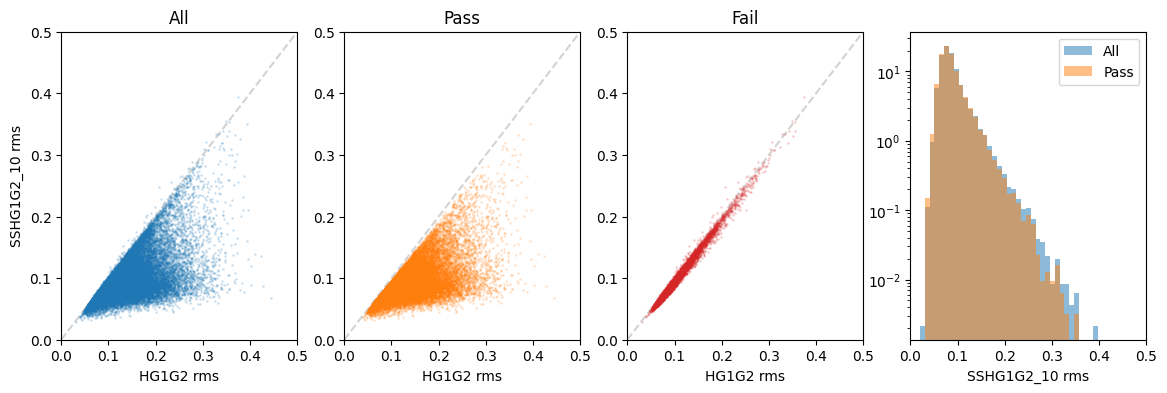

In [24]:
import matplotlib as mpl

fig, ax = plt.subplots(1, 4, sharey=False, figsize=(14,4))#, gridspec_kw={"wspace": 0.1})

m1 = 'HG1G2'
m2 = 'SSHG1G2_10'

rms_range = [0,0.5]
bins = np.linspace(0, 0.5, 50)

cond1 = data['ssnamenr'].notna()
cond2 = (data[f"F_{m1}_{m2}_pass"] == 1)

ax[0].scatter( data.loc[cond1, f"{m1}_rms"], data.loc[cond1, f"{m2}_rms"], s=1, alpha=0.15)

ax[1].scatter( data.loc[cond2, f"{m1}_rms"], data.loc[cond2, f"{m2}_rms"], s=1, alpha=0.15, color='C1')

ax[2].scatter( data.loc[~cond2, f"{m1}_rms"], data.loc[~cond2, f"{m2}_rms"], s=1, alpha=0.15, color='C3')


ax[3].hist( data.loc[cond1, f"{m2}_rms"], label="All", bins=bins, alpha=0.5, density=True)
ax[3].hist( data.loc[cond2, f"{m2}_rms"], label="Pass", bins=bins, alpha=0.5, density=True)
# ax[3].hist( data.loc[~cond2, f"{m2}_rms"], color='C3', label="Fail", bins=bins, alpha=0.5, density=True)


ax[0].set_ylabel(f"{m2} rms")
ax[0].set_title("All")
ax[1].set_title("Pass")
ax[2].set_title("Fail")

for a in ax:
    a.set_xlim(rms_range)
    a.set_xlabel(f"{m1} rms")

for a in ax[:3]:
    a.set_ylim(rms_range)
    a.plot( rms_range, rms_range, color='lightgrey', linestyle='--', zorder=-10)

ax[3].set_yscale('log')
ax[3].set_xlabel(f"{m2} rms")
ax[3].legend(loc='upper right')


print(f'{m1:10s} {len(data):}    and     {m2:10s} {len(data.loc[cond2])}')

45263 17515 38.69606521883216


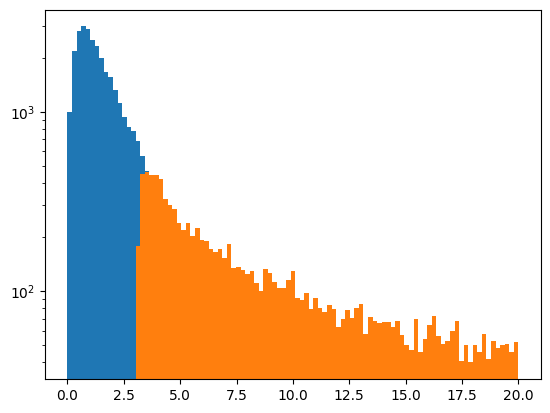

In [ ]:
# Illustratio of the F-test selection
fig, ax = plt.subplots()

m1 = "HG"
m2 = "SHG1G2"

bins = np.linspace(0, 20, 100)

alpha = scipy.stats.f.ppf(
    q=confidence_fraction, dfn=n_params[m2] - n_params[m1], dfd=N - n_params[m2]
)
ax.hist(data[f"F_{m1}_{m2}"], bins=bins)

cond = data[f"F_{m1}_{m2}"] > alpha
ax.hist(data.loc[cond, f"F_{m1}_{m2}"], bins=bins)
ax.set_yscale("log")

print(len(data), len(data.loc[cond]), 100 * len(data.loc[cond]) / len(data))

# RMS of SSHGG

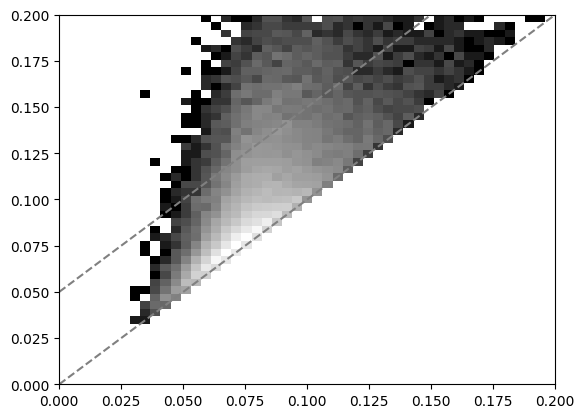

In [37]:
fig, ax = plt.subplots()


m1 = 'HG1G2'
m2 = 'SSHG1G2_00'
m3 = 'SSHG1G2_00'

# cond = (data[f"F_{m1}_{m2}_pass"] == 1) & (data[f"F_{m1}_{m3}_pass"] == 1)

rms_range = [0,0.2]
bins = np.linspace(0, 0.2, 50)

cond1 = data['ssnamenr'].notna()
cond2 = (data[f"F_{m1}_{m2}_pass"] == 1)


# ax.scatter( data.loc[cond1, 'SSHG1G2_min'], data.loc[cond1, 'SSHG1G2_max'], s=2, alpha=0.15 )
# ax.scatter( data.loc[cond2, 'SSHG1G2_min'], data.loc[cond2, 'SSHG1G2_max'], s=2, alpha=0.15 )


import matplotlib as mpl


ax.hist2d( data.loc[cond2, 'SSHG1G2_min'], data.loc[cond2, 'SSHG1G2_max'], bins=bins, norm=mpl.colors.LogNorm(), cmap=mpl.cm.gray);
ax.plot( rms_range, rms_range, color='grey', linestyle='--')
ax.plot( rms_range, np.array(rms_range)+0.05, color='grey', linestyle='--')



In [47]:
data[data.sso_number == 17365]

,ssnamenr,HG_chi2red,HG_status,HG_fit,HG_rms,HG_rms_g,HG_rms_r,HG_median_error_phot,HG_median_error_phot_1,HG_median_error_phot_2,...,F_HG1G2_SSHG1G2_11,F_HG1G2_SSHG1G2_11_pass,F_SHG1G2_SSHG1G2_00,F_SHG1G2_SSHG1G2_00_pass,F_SHG1G2_SSHG1G2_01,F_SHG1G2_SSHG1G2_01_pass,F_SHG1G2_SSHG1G2_10,F_SHG1G2_SSHG1G2_10_pass,F_SHG1G2_SSHG1G2_11,F_SHG1G2_SSHG1G2_11_pass


In [45]:
# data[     ["SSHG1G2_rms_00", "SSHG1G2_rms_01", "SSHG1G2_rms_10", "SSHG1G2_rms_11"]]
data[     ["sso_number", "SSHG1G2_chi2red_11", "SSHG1G2_chi2red_01", "SSHG1G2_chi2red_10", "SSHG1G2_chi2red_11"]]

,sso_number,SSHG1G2_chi2red_11,SSHG1G2_chi2red_01,SSHG1G2_chi2red_10,SSHG1G2_chi2red_11
0,83449,1.828617,2.057060,1.956824,1.828617
1,66572,0.430437,0.425664,0.397270,0.430437
2,6679,1.277953,1.385306,1.161397,1.277953
3,61723,5.842380,4.734508,7.763953,5.842380
4,36462,1.531263,1.058448,2.397372,1.531263
...,...,...,...,...,...
45258,45004,1.086848,1.035497,1.045881,1.086848
45259,43770,0.738858,0.835888,0.694162,0.738858
45260,158236,0.570325,0.852892,0.551538,0.570325
45261,25850,4.149188,3.755134,3.033827,4.149188


## Period differneces

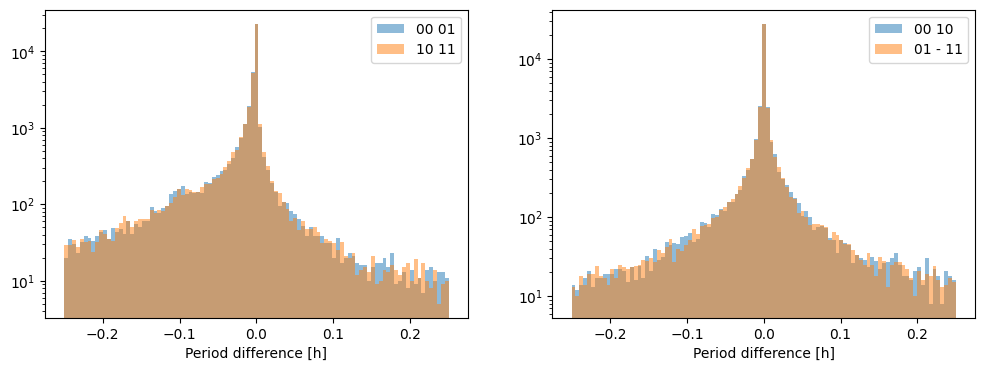

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(-0.25, 0.25, 100)
ax[0].hist(
    data["SSHG1G2_period_00"] - data["SSHG1G2_period_01"],
    bins=bins,
    alpha=0.5,
    label="00 01",
)
ax[0].hist(
    data["SSHG1G2_period_10"] - data["SSHG1G2_period_11"],
    bins=bins,
    alpha=0.5,
    label="10 11",
)

ax[1].hist(
    data["SSHG1G2_period_00"] - data["SSHG1G2_period_10"],
    bins=bins,
    alpha=0.5,
    label="00 10",
)
ax[1].hist(
    data["SSHG1G2_period_01"] - data["SSHG1G2_period_11"],
    bins=bins,
    alpha=0.5,
    label="01 - 11",
)

for a in ax:
    a.set_yscale("log")
    a.legend(loc="upper right")
    a.set_xlabel("Period difference [h]")

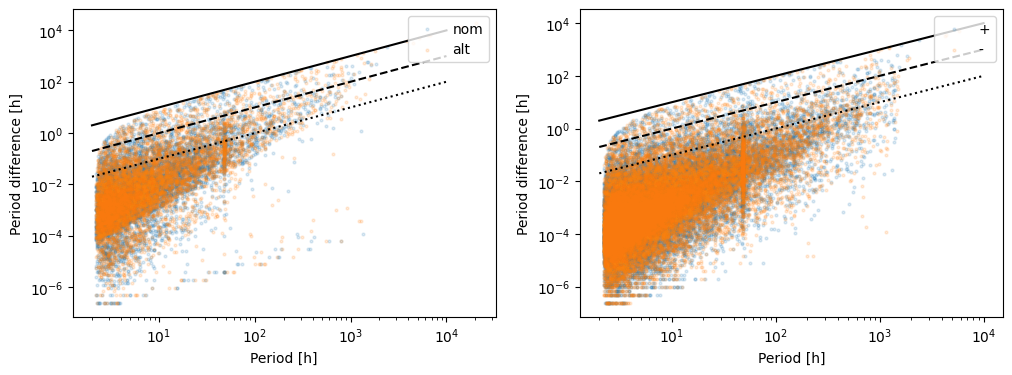

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(-0.25, 0.25, 100)


ax[0].scatter(
    data["SSHG1G2_period_00"],
    data["SSHG1G2_period_00"] - data["SSHG1G2_period_01"],
    s=4,
    alpha=0.15,
    label="nom",
)
ax[0].scatter(
    data["SSHG1G2_period_10"],
    data["SSHG1G2_period_10"] - data["SSHG1G2_period_11"],
    s=4,
    alpha=0.15,
    label="alt",
)

ax[1].scatter(
    data["SSHG1G2_period_00"],
    data["SSHG1G2_period_00"] - data["SSHG1G2_period_10"],
    s=4,
    alpha=0.15,
    label="+",
)
ax[1].scatter(
    data["SSHG1G2_period_01"],
    data["SSHG1G2_period_01"] - data["SSHG1G2_period_11"],
    s=4,
    alpha=0.15,
    label="-",
)

xx = np.linspace(2, 1e4, 1000)
for a in ax:
    a.set_xscale("log")
    a.set_yscale("log")
    a.legend(loc="upper right")
    a.set_xlabel("Period [h]")
    a.set_ylabel("Period difference [h]")

    a.plot(xx, 1 * xx, color="black", linestyle="solid")
    a.plot(xx, 0.1 * xx, color="black", linestyle="--")
    a.plot(xx, 0.01 * xx, color="black", linestyle="dotted")

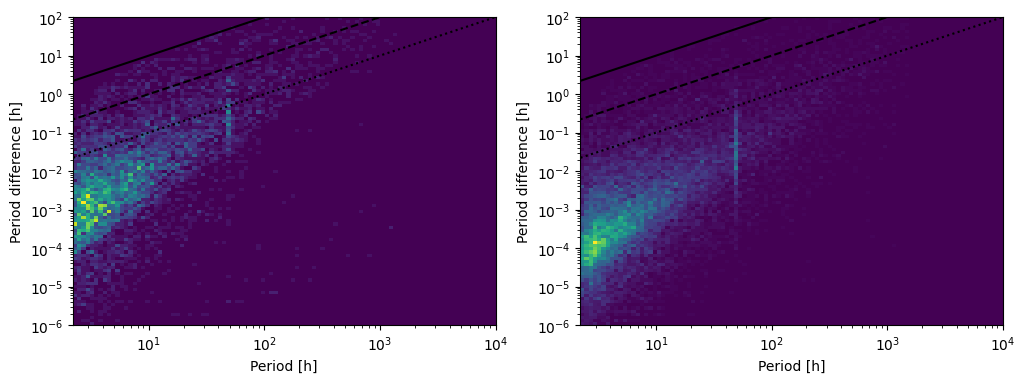

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(-0.25, 0.25, 100)


bins_x = np.logspace(np.log10(2.2), 4, 100)
bins_y = np.logspace(-6, 2, 100)
ax[0].hist2d(
    data["SSHG1G2_period_00"],
    data["SSHG1G2_period_00"] - data["SSHG1G2_period_01"],
    bins=(bins_x, bins_y),
    label="nom",
)
ax[0].hist2d(
    data["SSHG1G2_period_10"],
    data["SSHG1G2_period_10"] - data["SSHG1G2_period_11"],
    bins=(bins_x, bins_y),
    label="alt",
)

ax[1].hist2d(
    data["SSHG1G2_period_00"],
    data["SSHG1G2_period_00"] - data["SSHG1G2_period_10"],
    bins=(bins_x, bins_y),
    label="+",
)
ax[1].hist2d(
    data["SSHG1G2_period_01"],
    data["SSHG1G2_period_01"] - data["SSHG1G2_period_11"],
    bins=(bins_x, bins_y),
    label="-",
)

xx = np.linspace(2, 1e4, 1000)
for a in ax:
    a.set_xscale("log")
    a.set_yscale("log")
    a.set_xlabel("Period [h]")
    a.set_ylabel("Period difference [h]")

    a.plot(xx, 1 * xx, color="black", linestyle="solid")
    a.plot(xx, 0.1 * xx, color="black", linestyle="--")
    a.plot(xx, 0.01 * xx, color="black", linestyle="dotted")

## Spin coordinates

In [17]:
cond = data["spins.1.RA0.value"].notna()

In [18]:
cond = mask
for v1, v2 in (["00", "01"], ["10", "11"], ["00", "10"], ["01", "11"]):
    data.loc[cond, f"angular_separation_{v1}_{v2}"] = np.degrees(
        data.loc[
            cond,
            [
                f"SSHG1G2_alpha0_{v1}",
                f"SSHG1G2_delta0_{v1}",
                f"SSHG1G2_alpha0_{v2}",
                f"SSHG1G2_delta0_{v2}",
            ],
        ].apply(
            lambda x: angular_separation(
                np.radians(x.iloc[0]),
                np.radians(x.iloc[1]),
                np.radians(x.iloc[2]),
                np.radians(x.iloc[3]),
            ),
            axis=1,
        )
    )

00 01
10 11
00 10
01 11


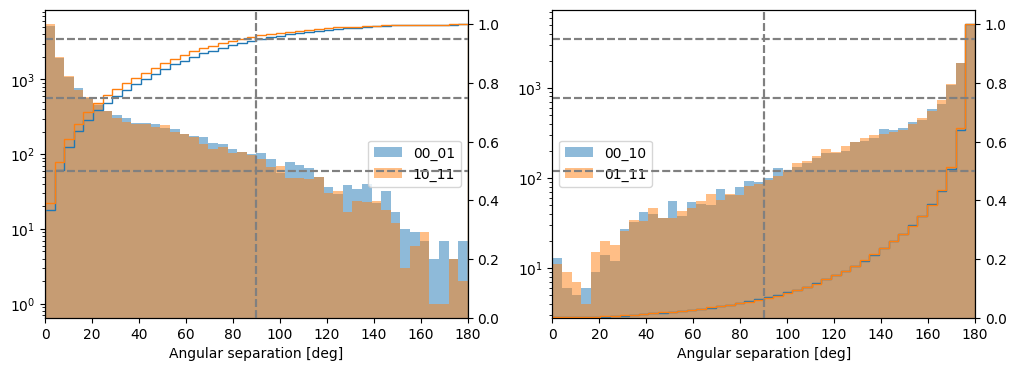

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, 180, 45)
cond = mask

k = -1
ax20 = ax[0].twinx()
ax21 = ax[1].twinx()
ax2 = [ax20, ax21]
for v1, v2 in (["00", "01"], ["10", "11"], ["00", "10"], ["01", "11"]):
    k = k + 1
    print(v1, v2)

    if k < 2:
        i = 0
    else:
        i = 1

    ax[i].hist(
        data.loc[cond, f"angular_separation_{v1}_{v2}"],
        bins=bins,
        alpha=0.5,
        label=f"{v1}_{v2}",
    )
    ax2[i].hist(
        data.loc[cond, f"angular_separation_{v1}_{v2}"],
        bins=bins,
        label=f"{v1}_{v2}",
        density=True,
        histtype="step",
        cumulative=True,
    )

    ax2[i].axhline(0.5, color="grey", linestyle="--")
    ax2[i].axhline(0.75, color="grey", linestyle="--")
    ax2[i].axhline(0.95, color="grey", linestyle="--")
    ax2[i].axvline(90, color="grey", linestyle="--")

for a in ax:
    a.set_yscale("log")
    a.set_xlim(0, 180)
    a.set_xlabel("Angular separation [deg]")

ax[0].legend(loc="center right")
ax[1].legend(loc="center left")

Text(0.5, 0, 'DEC [deg]')

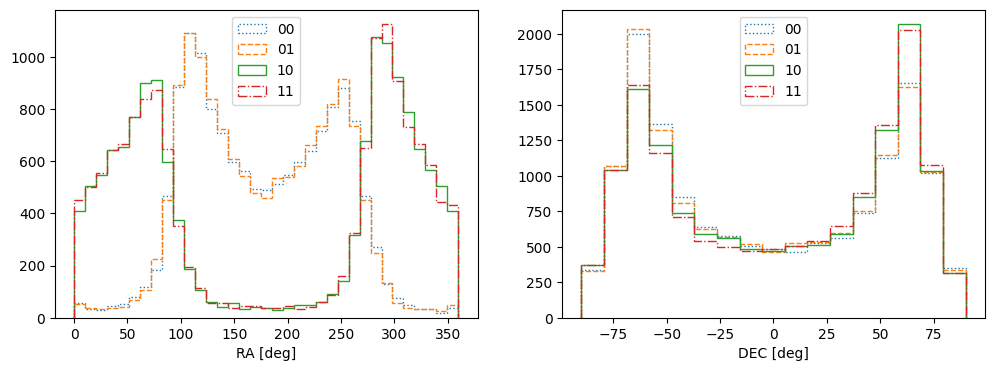

In [38]:
versions = ["00", "01", "10", "11"]
cond = mask

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

binRA = np.linspace(0, 360, 36)
binDEC = np.linspace(-90, 90, 18)

ls = [
    "dotted",
    "--",
    "solid",
    "-.",
]
for i, v in enumerate(versions):
    c2 = cond & (data[f"F_{m1}_{m2}_pass"] == 1)

    ax[0].hist(
        data.loc[cond, f"SSHG1G2_alpha0_{v}"],
        bins=binRA,
        histtype="step",
        linestyle=ls[i],
        label=v,
    )
    ax[1].hist(
        data.loc[cond, f"SSHG1G2_delta0_{v}"],
        bins=binDEC,
        histtype="step",
        linestyle=ls[i],
        label=v,
    )

ax[0].legend(loc="upper center")
ax[1].legend(loc="upper center")

ax[0].set_xlabel("RA [deg]")
ax[1].set_xlabel("DEC [deg]")

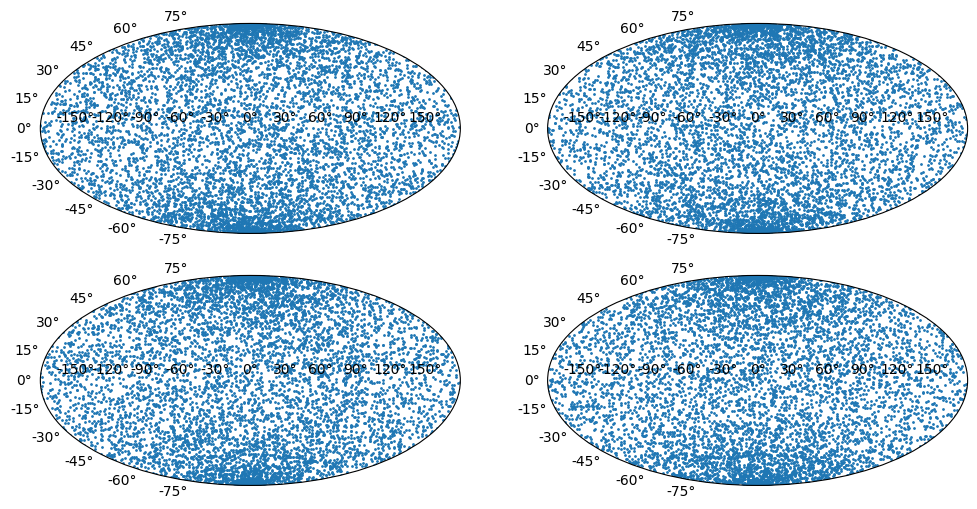

In [ ]:
versions = ["00", "01", "10", "11"]
cond = mask

fig, ax = plt.subplots(
    2,
    2,
    figsize=(12, 6),
    subplot_kw={"projection": "aitoff"},
)

axs = ax.flatten()
for i, v in enumerate(versions):

    axs[i].scatter(
        data.loc[cond, f"SSHG1G2_alpha0_{v}"],
        data.loc[cond, f"SSHG1G2_delta0_{v}"],
        s=1,
    )
    # axs[i].set_projection('aitoff')

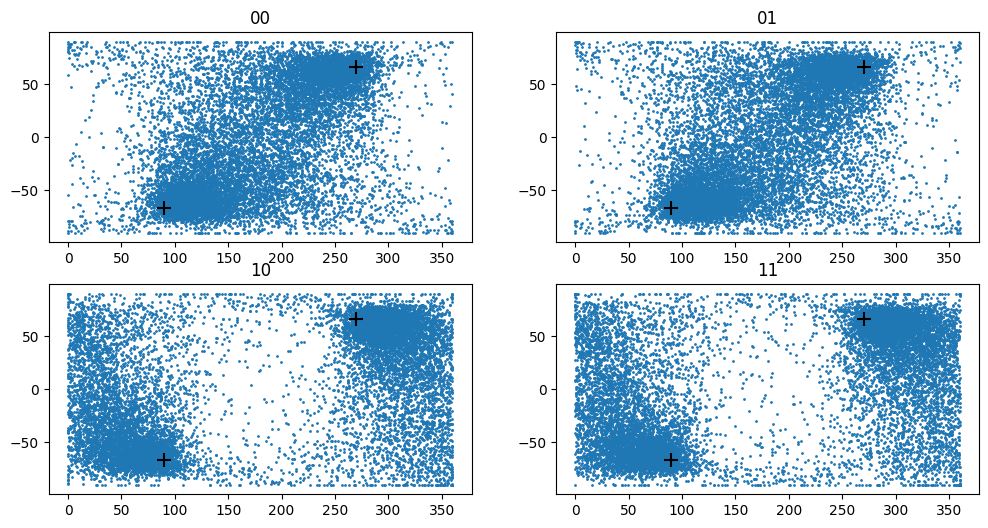

In [ ]:
versions = ["00", "01", "10", "11"]
cond = mask

fig, ax = plt.subplots(2, 2, figsize=(12, 6))

from astropy.coordinates import SkyCoord

EC1 = SkyCoord(lon=0, lat=90, unit="deg", frame="geocentricmeanecliptic")
EC2 = SkyCoord(lon=0, lat=-90, unit="deg", frame="geocentricmeanecliptic")

axs = ax.flatten()
for i, v in enumerate(versions):

    axs[i].scatter(
        data.loc[cond, f"SSHG1G2_alpha0_{v}"],
        data.loc[cond, f"SSHG1G2_delta0_{v}"],
        s=1,
    )
    axs[i].scatter(
        EC1.transform_to("icrs").ra.deg,
        EC1.transform_to("icrs").dec.deg,
        marker="+",
        s=100,
        color="black",
    )
    axs[i].scatter(
        EC2.transform_to("icrs").ra.deg,
        EC2.transform_to("icrs").dec.deg,
        marker="+",
        s=100,
        color="black",
    )
    axs[i].set_title(v)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'DEC [deg]')

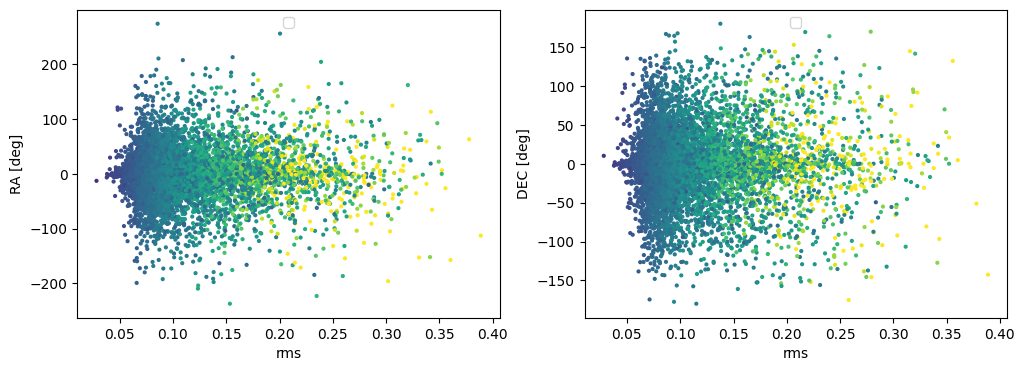

In [35]:
versions = ["00", "01", "10", "11"]
cond = mask

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

binRA = np.linspace(0, 360, 36)
binDEC = np.linspace(-90, 90, 18)

ls = [
    "dotted",
    "--",
    "solid",
    "-.",
]
# for i,v in enumerate(versions):

v1, v2 = "00", "01"
vmin, vmax = 0, 0.2
ax[0].scatter(
    data.loc[cond, f"SHG1G2_rms"],
    data.loc[cond, f"SSHG1G2_alpha0_{v1}"] - data.loc[cond, f"SSHG1G2_alpha0_{v2}"],
    s=4,
    vmin=vmin, vmax=vmax,
    c=data.loc[cond, f"SSHG1G2_rms_{v2}"],
)
ax[1].scatter(
    data.loc[cond, f"SHG1G2_rms"],
    data.loc[cond, f"SSHG1G2_delta0_{v1}"] - data.loc[cond, f"SSHG1G2_delta0_{v2}"],
    s=4,
    c=data.loc[cond, f"SSHG1G2_rms_{v2}"],
    vmin=vmin, vmax=vmax
)

ax[0].legend(loc="upper center")
ax[1].legend(loc="upper center")

ax[0].set_xlabel("rms")
ax[1].set_xlabel("rms")
ax[0].set_ylabel("RA [deg]")
ax[1].set_ylabel("DEC [deg]")

In [32]:
versions = ["00", "01", "10", "11"]
cond = mask

for v in versions:
    data.loc[cond, f"angular_separation_{v}"] = np.degrees(
        data.loc[
            cond,
            [
                f"SSHG1G2_alpha0_{v}",
                f"SSHG1G2_delta0_{v}",
                "spins.1.RA0.value",
                "spins.1.DEC0.value",
            ],
        ].apply(
            lambda x: angular_separation(
                np.radians(x.iloc[0]),
                np.radians(x.iloc[1]),
                np.radians(x.iloc[2]),
                np.radians(x.iloc[3]),
            ),
            axis=1,
        )
    )

    data.loc[cond, f"angular_separation_SS"] = np.degrees(
        data.loc[
            cond,
            [
                f"SHG1G2_alpha0",
                f"SHG1G2_delta0",
                "spins.1.RA0.value",
                "spins.1.DEC0.value",
            ],
        ].apply(
            lambda x: angular_separation(
                np.radians(x.iloc[0]),
                np.radians(x.iloc[1]),
                np.radians(x.iloc[2]),
                np.radians(x.iloc[3]),
            ),
            axis=1,
        )
    )

In [33]:
data["spins.1.technique"].value_counts()

spins.1.technique
A-M       27942
LCI        3024
LC         2190
LC+TPM      172
ADAM         13
LC-TPM       11
LC+Occ        9
Radar         3
LC+IM         3
TE            3
SPACE         2
SAGE          2
Name: count, dtype: int64

00 45263 30049 9779 3024 6623 824
10 45263 30049 9779 3024 6623 824


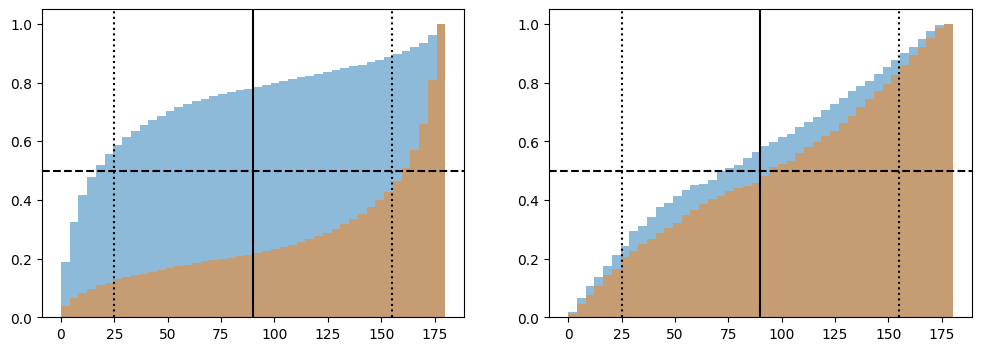

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, 180, 45)
versions = ["00", "10"]


for v in versions:

    c_ang = data[f"angular_separation_{v}"].notna()
    cond = data[f"F_HG_SSHG1G2_00_pass"] == True
    c_tech = data["spins.1.technique"] == "LCI"

    ax[0].hist(
        data.loc[c_ang, f"angular_separation_{v}"],
        density=True,
        cumulative=True,
        alpha=0.5,
        bins=bins,
    )

    ax[1].hist(
        data.loc[cond & c_ang & c_tech, f"angular_separation_{v}"],
        density=True,
        cumulative=True,
        alpha=0.5,
        bins=bins,
    )

    print(
        v,
        len(data),
        len(data.loc[cond]),
        len(data.loc[c_ang]),
        len(data.loc[c_tech]),
        len(data.loc[cond & c_ang]),
        len(data.loc[cond & c_ang & c_tech]),
    )


for a in ax:
    a.axhline(0.5, color="black", linestyle="--")
    a.axvline(90, color="black", linestyle="solid")
    a.axvline(25, color="black", linestyle="dotted")
    a.axvline(180 - 25, color="black", linestyle="dotted")

In [ ]:
data[f"F_HG_SSHG1G2_pass"].value_counts()

## Chi2 - RMS?

In [ ]:
fig, ax = plt.subplots(
    4,
    4,
    figsize=(8, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0, "wspace": 0},
)

versions = ["00", "01", "10", "11"]
bins = np.linspace(0, 0.5, 50)
for i1, v1 in enumerate(versions):
    ax[i1, 0].set_ylabel(f"rms {v1}")
    ax[3, i1].set_xlabel(f"rms {v1}")

    for i2, v2 in enumerate(versions):

        ax[i1, i2].hist2d(
            data[f"SSHG1G2_rms_{v1}"],
            data[f"SSHG1G2_rms_{v2}"],
            bins=bins,
            density=True,
            vmin=1,
            vmax=100,
        )

In [ ]:
fig, ax = plt.subplots(
    4,
    4,
    figsize=(8, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0, "wspace": 0},
)

versions = ["00", "01", "10", "11"]
bins = np.linspace(0, 2.5, 50)
for i1, v1 in enumerate(versions):
    ax[i1, 0].set_ylabel(f"chi2 {v1}")
    ax[3, i1].set_xlabel(f"chi2 {v1}")

    for i2, v2 in enumerate(versions):

        ax[i1, i2].hist2d(
            data[f"SSHG1G2_chi2red_{v1}"],
            data[f"SSHG1G2_chi2red_{v2}"],
            bins=bins,
            density=True,
            vmin=1,
            vmax=5,
        )

## Binaries

In [ ]:
bins = pd.read_csv(
    os.path.join("/", "astrocloud", "Satellite", "Naming", "asteroid_satellites.csv")
)

data[data.sso_name.isin(bins.system_name)].sort_values(
    "SHG1G2_rms", ascending=False
).head(35)